In [1]:
import pandas as pd

df = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data"
)

print(df)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

      vhigh vhigh.1      2   2.1  small   low  unacc
0     vhigh   vhigh      2     2  small   med  unacc
1     vhigh   vhigh      2     2  small  high  unacc
2     vhigh   vhigh      2     2    med   low  unacc
3     vhigh   vhigh      2     2    med   med  unacc
4     vhigh   vhigh      2     2    med  high  unacc
...     ...     ...    ...   ...    ...   ...    ...
1722    low     low  5more  more    med   med   good
1723    low     low  5more  more    med  high  vgood
1724    low     low  5more  more    big   low  unacc
1725    low     low  5more  more    big   med   good
1726    low     low  5more  more    big  high  vgood

[1727 rows x 7 columns]


In [2]:
col_names = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]

df.columns = col_names
print(df)

print(df.info())
print(df.describe(include="all"))
print(df.describe(include="all").T)

     buying  maint  doors persons lug_boot safety  class
0     vhigh  vhigh      2       2    small    med  unacc
1     vhigh  vhigh      2       2    small   high  unacc
2     vhigh  vhigh      2       2      med    low  unacc
3     vhigh  vhigh      2       2      med    med  unacc
4     vhigh  vhigh      2       2      med   high  unacc
...     ...    ...    ...     ...      ...    ...    ...
1722    low    low  5more    more      med    med   good
1723    low    low  5more    more      med   high  vgood
1724    low    low  5more    more      big    low  unacc
1725    low    low  5more    more      big    med   good
1726    low    low  5more    more      big   high  vgood

[1727 rows x 7 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1727 non-null   object
 1   maint     1727 non-null   object
 2   doors     1727 non-null   ob

In [3]:
for col in col_names:
    print(df[col].value_counts())


print(df.duplicated())
print(df[df.duplicated()])


from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder()
df["buying"] = oe.fit_transform(df[["buying"]])
df["maint"] = oe.fit_transform(df[["maint"]])
df["doors"] = oe.fit_transform(df[["doors"]])
df["persons"] = oe.fit_transform(df[["persons"]])
df["lug_boot"] = oe.fit_transform(df[["lug_boot"]])
df["safety"] = oe.fit_transform(df[["safety"]])
df["class"] = oe.fit_transform(df[["class"]])
print(df.head())

buying
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
maint
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
doors
3        432
4        432
5more    432
2        431
Name: count, dtype: int64
persons
4       576
more    576
2       575
Name: count, dtype: int64
lug_boot
med      576
big      576
small    575
Name: count, dtype: int64
safety
med     576
high    576
low     575
Name: count, dtype: int64
class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64
0       False
1       False
2       False
3       False
4       False
        ...  
1722    False
1723    False
1724    False
1725    False
1726    False
Length: 1727, dtype: bool
Empty DataFrame
Columns: [buying, maint, doors, persons, lug_boot, safety, class]
Index: []
   buying  maint  doors  persons  lug_boot  safety  class
0     3.0    3.0    0.0      0.0       2.0     2.0    2.0
1     3.0    3.0    0.0      0.0       2.0     0.0    2.0


In [4]:
x = df.iloc[:, 0:-1]
y = df.iloc[:, -1]
print(x)
print(y)


      buying  maint  doors  persons  lug_boot  safety
0        3.0    3.0    0.0      0.0       2.0     2.0
1        3.0    3.0    0.0      0.0       2.0     0.0
2        3.0    3.0    0.0      0.0       1.0     1.0
3        3.0    3.0    0.0      0.0       1.0     2.0
4        3.0    3.0    0.0      0.0       1.0     0.0
...      ...    ...    ...      ...       ...     ...
1722     1.0    1.0    3.0      2.0       1.0     2.0
1723     1.0    1.0    3.0      2.0       1.0     0.0
1724     1.0    1.0    3.0      2.0       0.0     1.0
1725     1.0    1.0    3.0      2.0       0.0     2.0
1726     1.0    1.0    3.0      2.0       0.0     0.0

[1727 rows x 6 columns]
0       2.0
1       2.0
2       2.0
3       2.0
4       2.0
       ... 
1722    1.0
1723    3.0
1724    2.0
1725    1.0
1726    3.0
Name: class, Length: 1727, dtype: float64


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, random_state=42, test_size=0.2
)
print(X_train)
print(y_train)


      buying  maint  doors  persons  lug_boot  safety
107      3.0    0.0    0.0      0.0       2.0     1.0
900      2.0    3.0    1.0      1.0       2.0     2.0
1708     1.0    1.0    3.0      0.0       0.0     0.0
705      0.0    2.0    2.0      0.0       1.0     2.0
678      0.0    2.0    1.0      0.0       1.0     2.0
...      ...    ...    ...      ...       ...     ...
1130     2.0    2.0    1.0      2.0       0.0     1.0
1294     2.0    1.0    3.0      2.0       0.0     0.0
860      0.0    1.0    3.0      2.0       0.0     1.0
1459     1.0    0.0    2.0      0.0       2.0     0.0
1126     2.0    2.0    1.0      2.0       2.0     0.0

[1381 rows x 6 columns]
107     2.0
900     2.0
1708    2.0
705     2.0
678     2.0
       ... 
1130    2.0
1294    3.0
860     2.0
1459    2.0
1126    0.0
Name: class, Length: 1381, dtype: float64


In [ ]:
from sklearn.ensemble import RandomForestClassifier

clf1 = RandomForestClassifier()
print(clf1.fit(X_train, y_train))

pred1 = clf1.predict(X_test)
print(pred1)

RandomForestClassifier()
[2. 2. 2. 0. 2. 0. 2. 2. 2. 2. 0. 2. 2. 2. 2. 2. 2. 2. 2. 0. 2. 2. 0. 2.
 2. 0. 2. 2. 2. 2. 0. 2. 2. 1. 2. 2. 1. 2. 2. 3. 0. 0. 2. 2. 1. 0. 2. 2.
 2. 2. 2. 2. 0. 0. 2. 2. 2. 2. 2. 0. 2. 2. 2. 2. 2. 3. 2. 2. 0. 2. 3. 0.
 2. 2. 2. 0. 2. 2. 2. 2. 3. 2. 2. 0. 2. 0. 2. 2. 0. 0. 2. 1. 2. 2. 2. 2.
 2. 2. 2. 0. 2. 2. 2. 2. 2. 1. 0. 2. 2. 0. 2. 0. 2. 2. 0. 2. 2. 2. 2. 2.
 2. 0. 2. 0. 0. 2. 0. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 0. 2. 0.
 2. 0. 2. 2. 0. 2. 0. 3. 2. 2. 2. 2. 2. 2. 2. 2. 0. 0. 2. 3. 2. 3. 0. 0.
 2. 3. 0. 2. 3. 2. 0. 0. 3. 2. 0. 2. 0. 2. 2. 0. 1. 2. 2. 2. 2. 2. 2. 0.
 0. 2. 2. 2. 0. 2. 2. 2. 2. 2. 2. 3. 2. 0. 2. 0. 2. 0. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 3. 3. 2. 2. 0. 3. 0. 0. 0. 2. 2. 0. 2. 2. 2. 0. 2. 0. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 0. 0. 2. 2. 2. 2. 2. 0. 2. 3. 2.
 2. 2. 0. 0. 2. 2. 2. 2. 0. 2. 0. 0. 2. 1. 2. 2. 2. 1. 2. 0. 0. 0. 2. 1.
 3. 2. 1. 2. 2. 2. 0. 3. 2. 2. 2. 2. 0. 0. 2. 2. 2. 2. 2. 2. 0. 2. 3. 2.
 2. 2. 2. 0. 0. 0. 2. 2. 2

0.9682080924855492


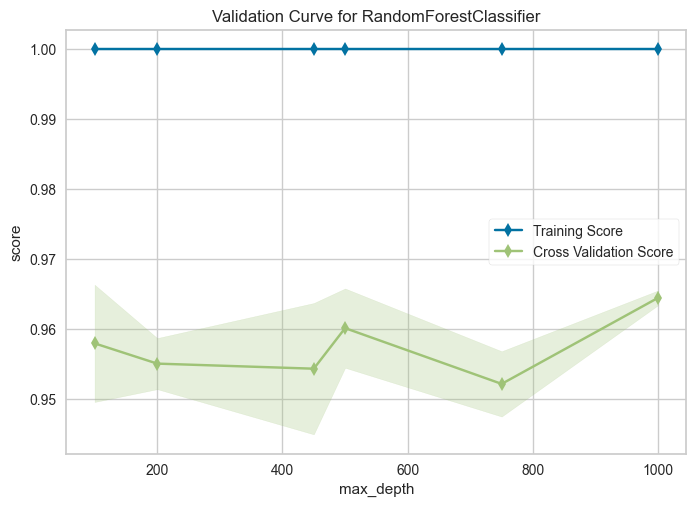

ValidationCurve(ax=<Axes: title={'center': 'Validation Curve for RandomForestClassifier'}, xlabel='max_depth', ylabel='score'>,
                cv=3, estimator=RandomForestClassifier(),
                param_name='max_depth',
                param_range=array([ 100,  200,  450,  500,  750, 1000]),
                scoring='accuracy')


In [7]:
from sklearn.metrics import accuracy_score

print(accuracy_score(pred1, y_test))


from yellowbrick.model_selection import validation_curve

num_est = [100, 200, 450, 500, 750, 1000]
print(
    validation_curve(
        RandomForestClassifier(),
        X=X_train,
        y=y_train,
        param_name="max_depth",
        param_range=num_est,
        scoring="accuracy",
        cv=3,
    )
)


In [8]:

clf2 = RandomForestClassifier(
    n_estimators=1000, min_samples_split=3, max_depth=15, random_state=0
)

clf2.fit(X_train, y_train)

pred2 = clf2.predict(X_test)
print(accuracy_score(pred2, y_test))

feature_scores = pd.Series(
    clf2.feature_importances_, index=X_train.columns
).sort_values(ascending=False)
print(feature_scores)

0.9710982658959537
safety      0.288136
persons     0.233230
buying      0.185180
maint       0.149029
lug_boot    0.082086
doors       0.062340
dtype: float64


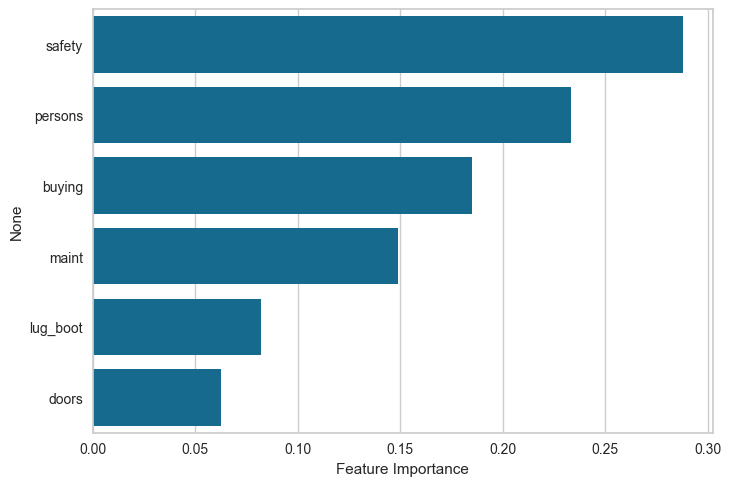

In [9]:
sns.barplot(x=feature_scores, y=feature_scores.index)
plt.xlabel("Feature Importance")
plt.show()


In [10]:
clf3 = RandomForestClassifier()
Xn = df.drop(["doors", "lug_boot", "maint"], axis=1)
yn = df["class"]
X_trainn, X_testn, y_trainn, y_testn = train_test_split(Xn, yn, test_size=0.3)
clf3.fit(X_trainn, y_trainn)
new_pred = clf3.predict(X_testn)
print(accuracy_score(new_pred, y_testn))

1.0
